# **ERC en población afrodescendiente: base de datos**

In [347]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import math

##### **Funciones**

In [348]:
def resumen_var_cat(df):
    conteo = df.value_counts(dropna=False)
    porcentaje = df.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'Categorías': conteo.index,
        'Conteo': conteo.values,
        'Porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(10) 
    
    styled = resumen.style \
        .format({'porcentaje': '{:.2f}%'})
    
    display(styled)

In [349]:
def Resumen_Faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

In [350]:
def analizar_distribucion(df, columna, color="#4682B4"):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                        gridspec_kw={"height_ratios": (.15, .85)},
                                        figsize=(8, 6))
    
    sns.boxplot(x=df[columna], ax=ax_box, color=color, fliersize=5)
    ax_box.set(xlabel='') 
    ax_box.set_title(f'Distribución de la Variable: {columna}', fontsize=14)
    
    sns.histplot(df[columna], ax=ax_hist, kde=True, color=color, bins=30)
    ax_hist.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()
    plt.show()

### **Base de datos**

In [351]:
df = pd.read_excel("df_afro_clean.xlsx")

In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GRUPO                         1357 non-null   object 
 1   Departamento_Tamizaje         1357 non-null   object 
 2   Municipio_Tamizaje            1357 non-null   object 
 3   Edad                          1357 non-null   int64  
 4   Genero                        1357 non-null   object 
 5   Escolaridad                   1357 non-null   object 
 6   Regimen_Salud                 1357 non-null   object 
 7   Ocupacion                     1357 non-null   object 
 8   Medicacion_Diabetes           1357 non-null   object 
 9   Diabetes_Embarazo             1357 non-null   object 
 10  Hipertension                  1357 non-null   object 
 11  Medicacion_Hipertension       1357 non-null   object 
 12  Colesterol_Alto               1357 non-null   object 
 13  Med

In [353]:
df["Presion_Sistolica	> 130"] = df["Presion_Sistolica	> 130"].astype("object")
df["Presion_Diastolica > 90"] = df["Presion_Diastolica > 90"].astype("object")

### **Verificación de registros duplicados:**

In [354]:
print("En este dataset podemos encontrar {} resgistros duplicados".format(df.duplicated().sum()))

En este dataset podemos encontrar 1 resgistros duplicados


In [355]:
df[df.duplicated(keep = False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
407,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,...,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto
1023,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,...,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto


Ante la presencia de un registro duplicado, se conserva el que aparece en primer lugar y se elimina aquel que se encuentra en una posición posterior, bajo el supuesto de que el primer registro corresponde a la captura original y los siguientes podrían derivarse de errores de digitación, reprocesamiento o redundancias en la recolección de la información.

In [356]:
df= df.drop_duplicates(keep='first')
print("Dentro del dataset aun quedan {} registros duplicados".format(df.duplicated().sum()))

Dentro del dataset aun quedan 0 registros duplicados


In [357]:
df[df.duplicated(keep=False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC


Finalmente, la base de datos contaría con 1356 individuos.

### **Verificación de lugares de tamizajes**

**Departamentos**

In [358]:
df['Departamento_Tamizaje'].unique()

array(['BOLIVAR', 'ATLANTICO', 'PALENQUE'], dtype=object)

In [359]:
df["Departamento_Tamizaje"] = df["Departamento_Tamizaje"].replace({
    "PALENQUE":"BOLIVAR"
})

In [360]:
df['Departamento_Tamizaje'].unique()

array(['BOLIVAR', 'ATLANTICO'], dtype=object)

**Municipios**

In [361]:
df['Municipio_Tamizaje'].unique()

array(['MARIA LA BAJA', 'BARRANQUILLA', 'PALENQUE', 'LOMITA ARENA',
       'PONTEZUELA', 'SAN JOSE DE SACO'], dtype=object)

In [362]:
relacion = df.groupby('Departamento_Tamizaje')['Municipio_Tamizaje'].unique()

for depto, municipios in relacion.items():
    print(f"** {depto} **")
    print(f"{', '.join(municipios)}\n")

** ATLANTICO **
BARRANQUILLA, SAN JOSE DE SACO

** BOLIVAR **
MARIA LA BAJA, PALENQUE, LOMITA ARENA, PONTEZUELA



**Individuos mayores a 18 años**

In [363]:
print(f"El valor de la muestra hasta ahora {len(df)}")
print(f"El número de personas menores de 18 años es {len(df[df['Edad']<18])}")
df = df[df['Edad']>=18]
print(f"La muestra excluyendo a los menores de 18 años es de {len(df)} registros")

El valor de la muestra hasta ahora 1356
El número de personas menores de 18 años es 13
La muestra excluyendo a los menores de 18 años es de 1343 registros


Después de filtrar los datos según el criterio de exclusión: individuos de 18 años o mayores, resultan **1343 individuos**.

**Observación con información pérdida en la varible 'Regimen_Salud'**

In [364]:
df['Regimen_Salud'].unique()

array(['Subsidiado', 'No tiene', 'Contributivo', 'Especial', 'N.d.'],
      dtype=object)

In [365]:
df[df["Regimen_Salud"]=="N.d."]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
1233,AFRODESCENDIENTE,BOLIVAR,PALENQUE,58,Femenino,No escolarizado,N.d.,Desempleado,No,No,...,NaN,NaN,120.0,87.0,No,0,0,1.61-1.70,41-60,Normal


**Observaciones con valores anómalos en la variable 'Peso'**

In [366]:
df[df['Peso']<35]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
50,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,70,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,149.0,79.0,No,1,0,1.61-1.70,<40,Bajo
51,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,61,Femenino,No escolarizado,Subsidiado,Agricultor,Si,No,...,NaN,NaN,159.0,90.0,No,1,0,1.61-1.70,<40,Bajo
91,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,50,Femenino,Técnica,Subsidiado,Desempleado,No,No,...,117.09,80.0,117.0,82.0,No,0,0,1.50-1.60,<40,Bajo
769,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,70,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,149.0,79.0,No,1,0,1.61-1.70,<40,Bajo
795,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,50,Femenino,Técnica,Subsidiado,Desempleado,No,No,...,NaN,NaN,117.0,82.0,No,0,0,1.50-1.60,<40,Bajo


**Observaciones con valores anómalos de IMC**

In [367]:
df[df['IMC']<15]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
50,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,70,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,149.0,79.0,No,1,0,1.61-1.70,<40,Bajo
51,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,61,Femenino,No escolarizado,Subsidiado,Agricultor,Si,No,...,NaN,NaN,159.0,90.0,No,1,0,1.61-1.70,<40,Bajo
55,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,72,Femenino,Primaria,Subsidiado,Desempleado,No,No,...,NaN,NaN,172.0,84.0,No,1,0,>1.70,<40,Bajo
69,AFRODESCENDIENTE,BOLIVAR,PALENQUE,56,Femenino,Universitaria,Contributivo,Otro,No,No,...,NaN,NaN,119.0,93.0,No,0,1,>1.70,41-60,Bajo
83,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Posgrado,No tiene,Comerciante,No,No,...,NaN,NaN,117.0,80.0,No,0,0,>1.70,41-60,Bajo
91,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,50,Femenino,Técnica,Subsidiado,Desempleado,No,No,...,117.09,80.0,117.0,82.0,No,0,0,1.50-1.60,<40,Bajo
214,AFRODESCENDIENTE,BOLIVAR,LOMITA ARENA,47,Femenino,Secundaria,Subsidiado,Desempleado,No,No aplica,...,NaN,NaN,120.0,70.0,No,0,0,>1.70,41-60,Bajo
378,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,61,Femenino,Bachiller,Especial,Desempleado,No,No,...,NaN,NaN,120.0,80.0,No,0,0,>1.70,41-60,Bajo
434,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,24,Femenino,Universitaria,Subsidiado,Otro,No,No,...,NaN,NaN,114.0,75.0,No,0,0,1.61-1.70,<40,Bajo
531,AFRODESCENDIENTE,ATLANTICO,SAN JOSE DE SACO,88,Femenino,No escolarizado,Subsidiado,Desempleado,No,No,...,NaN,NaN,130.0,70.0,No,0,0,1.61-1.70,<40,Bajo


In [368]:
IMC_BAJO = df[df['IMC']<15]
len(IMC_BAJO)

15

In [369]:
df.loc[(df["Peso"]<35)&(df["IMC"]<15),["Peso","IMC","Talla"]]

,Peso,IMC,Talla
50,31,11.959415,1.61
51,24,9.144947,1.62
91,31,12.576575,1.57
769,31,11.959415,1.61
795,31,12.576575,1.57


Note que los 5 registros que cumplen con el peso $< 35kg$ tambien cumplen con la anomalia de tener un IMC $<15kg/m^2$

In [370]:
df.loc[(df["Peso"]>=35)&(df["IMC"]<15),["Peso","IMC","Talla"]]

,Peso,IMC,Talla
55,35,10.923504,1.79
69,42,12.962963,1.80
83,46,14.682882,1.77
214,45,14.202752,1.78
378,45,14.363689,1.77
434,40,14.172336,1.68
531,40,14.342572,1.67
782,42,12.962963,1.80
788,46,14.682882,1.77
1040,40,14.172336,1.68


Esto nos deja con 10 individuos que cumplen exclusivamente con el criterio de un IMC < 15 $kg/m^2$, debido a que presentan un peso significativamente bajo en relación con su estatura.

In [371]:
len(df)

1343

In [372]:
df = df[df['Regimen_Salud']!='N.d.']
df=df[((df['Peso']>=35)&(df["IMC"]>=15))]
len(df)

1327

In [373]:
df[df['Presion_Diastolica']>200]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
292,AFRODESCENDIENTE,ATLANTICO,SAN JOSE DE SACO,57,Masculino,Universitaria,Contributivo,Otro,No,No aplica,...,43.79,73.0,130.0,880.0,Si,0,1,1.50-1.60,61-80,Alto
935,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,57,Masculino,Universitaria,Contributivo,Otro,No,No aplica,...,64.18,73.0,130.0,880.0,Si,0,1,1.50-1.60,61-80,Alto


In [374]:
df["Presion_Diastolica"] = df["Presion_Diastolica"].replace(880.0, 88.0)

In [375]:
df[df['Presion_Diastolica']>200]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,...,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC


En total, se procedio a eliminar 16 registros unicos consolidando una muestra de **1327 individuos**.

### **Diagrama de Flujo Limpieza de Datos**

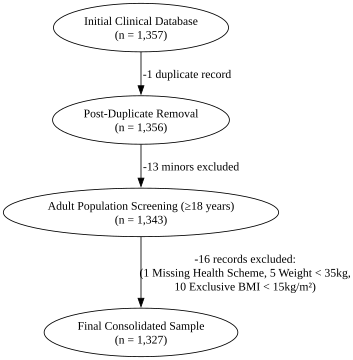

In [376]:
import graphviz

dot = graphviz.Digraph(comment='Data Cleaning Workflow')
dot.attr(rankdir='TB', size='8,5')

# Nodes - Using "Records" and "Observations" for technical precision
dot.node('A', 'Initial Clinical Database\n(n = 1,357)')
dot.node('B', 'Post-Duplicate Removal\n(n = 1,356)')
dot.node('C', 'Adult Population Screening (≥18 years)\n(n = 1,343)')
dot.node('D', 'Final Consolidated Sample\n(n = 1,327)')

# Edges - Using clear exclusion labels
dot.edge('A', 'B', label=' -1 duplicate record')
dot.edge('B', 'C', label=' -13 minors excluded')
dot.edge('C', 'D', label='-16 records excluded:\n(1 Missing Health Scheme, 5 Weight < 35kg,\n10 Exclusive BMI < 15kg/m²)')

dot.render('data_cleaning_flow', format='png', cleanup=True)
dot

### **Manipulación de la base de datos según recomendaciones:**

**Valores faltantes**

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


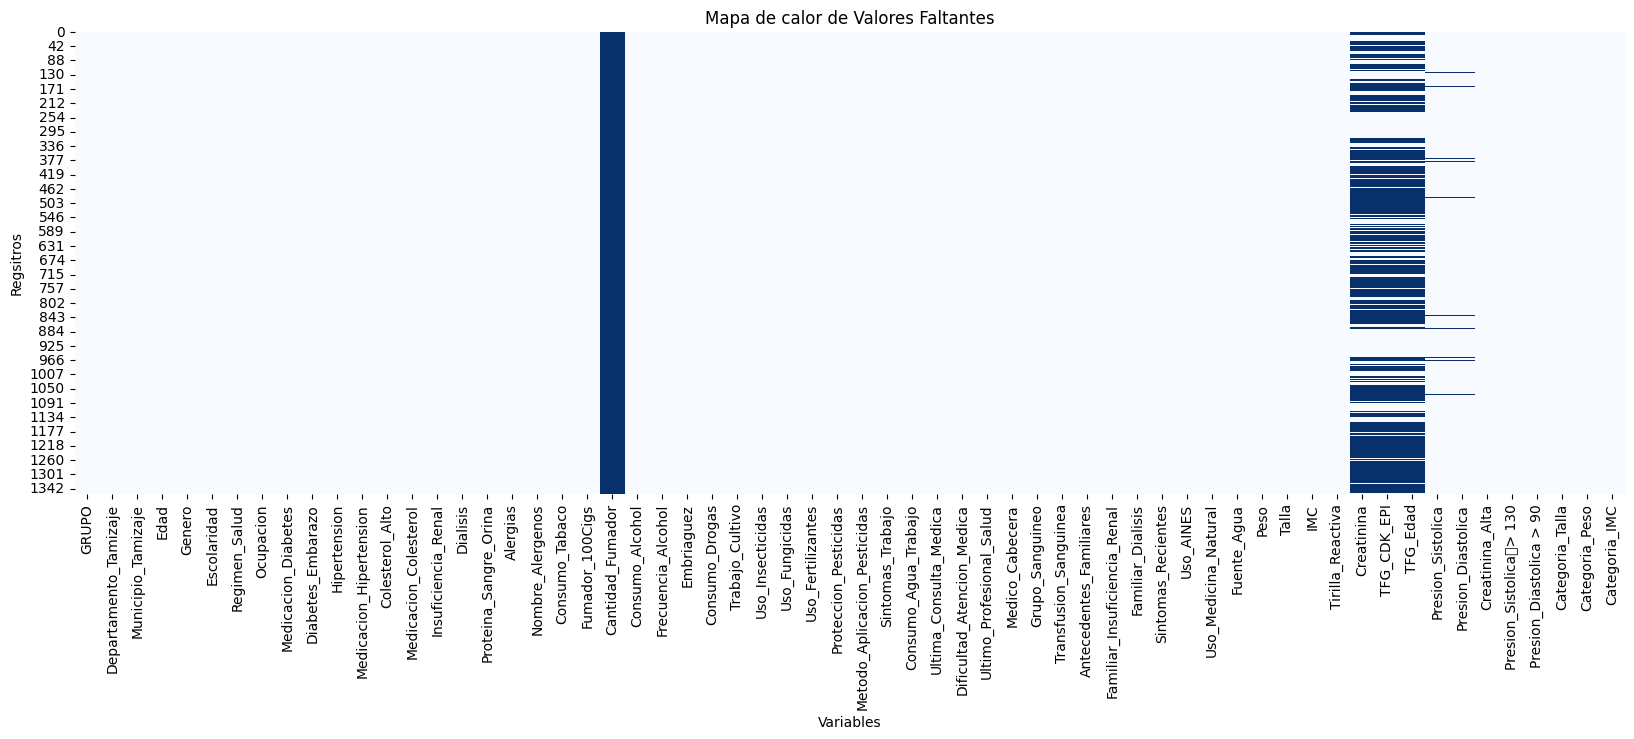

In [377]:
plt.figure(figsize = (20,6))
sns.heatmap(df.isnull(),cbar=False,cmap= "Blues")
plt.title("Mapa de calor de Valores Faltantes")
plt.xlabel("Variables")
plt.ylabel("Regsitros")
plt.show()

In [378]:
Resumen_Faltantes(df)

,Valores faltantes,Porcentaje (%)
Cantidad_Fumador,1327,100.000000
Creatinina,861,64.883195
TFG_CDK_EPI,861,64.883195
TFG_Edad,861,64.883195
Presion_Sistolica,47,3.541824
Presion_Diastolica,47,3.541824


La variable ``Cantidad_Fumador``, al encontrarse completamente vacía, será eliminada de la base de datos.

In [379]:
df = df.drop(columns = "Cantidad_Fumador")

 Por otro lado, las variables ``Presion_Sistolica`` y ``Presion_Diastolica`` presentan un 3.46% de valores faltantes (aproximadamente 47 registros), por lo que se imputa por la mediana, según las sugerencias dadas.

**Eliminación de variables**

In [380]:
var_eliminar = ['Alergias', 'Ocupacion', 'Embriaguez', 'Sintomas_Trabajo', 'Nombre_Alergenos']

df = df.drop(columns=var_eliminar)

**Reagrupación de categorías:**

In [381]:
df_agrupado = df.copy()

**`Escolaridad:`**

In [382]:
df_agrupado["Escolaridad"] = df_agrupado["Escolaridad"].replace({
    "Secundaria":"Secundaria-Bachiller",
    "Bachiller":"Secundaria-Bachiller",
    "Técnica":"Educación_Superior",
    "Tecnológa":"Educación_Superior",
    "Universitaria":"Educación_Superior",
    "Posgrado":"Educación_Superior",
    "Primaria":"No_escolarizado-Primaria",
    "No  escolarizado":"No_escolarizado-Primaria"
})

In [383]:
resumen_var_cat(df_agrupado["Escolaridad"])

,Categorías,Conteo,Porcentaje
0,Secundaria-Bachiller,467,35.190000
1,No_escolarizado-Primaria,458,34.510000
2,Educación_Superior,402,30.290000


**`Regimen_Salud:`**

In [384]:
df_agrupado["Regimen_Salud"] = df_agrupado["Regimen_Salud"].replace({
    "Contributivo": "Contributivo-Especial", 
    "Subsidiado": "Subsidiado-No_Tiene", 
    "Especial": "Contributivo-Especial", 
    "No tiene": "Subsidiado-No_Tiene"})

In [385]:
resumen_var_cat(df_agrupado["Regimen_Salud"])

,Categorías,Conteo,Porcentaje
0,Subsidiado-No_Tiene,971,73.170000
1,Contributivo-Especial,356,26.830000


**`Consumo_Agua_Trabajo:`**

In [386]:
df_agrupado["Consumo_Agua_Trabajo"] = df_agrupado["Consumo_Agua_Trabajo"].replace({
    "Mas de 1 litro": "Consumo adecuado", 
    "Mas de 200 cc": "No toma nada", 
    "Mas de 5 litros": "No toma nada", 
    "Menos de 100 cc": "Consumo elevado"
    })

In [387]:
resumen_var_cat(df_agrupado["Consumo_Agua_Trabajo"])

,Categorías,Conteo,Porcentaje
0,Consumo adecuado,763,57.500000
1,No toma nada,508,38.280000
2,Consumo elevado,56,4.220000


**`Frecuencia_Alcohol:`**

In [388]:
df_agrupado["Frecuencia_Alcohol"] = df_agrupado["Frecuencia_Alcohol"].replace({
    "Menos de 1 vez al mes":"Consumo_Ocasional",
    "1-2 veces por mes":"Consumo_Ocasional",
    "1-2 veces por semana":"Consumo_Frecuente",
    "3-4 veces por semana":"Consumo_Frecuente",
    "Diario":"Consumo_Habitual"})

In [389]:
resumen_var_cat(df_agrupado["Frecuencia_Alcohol"])

,Categorías,Conteo,Porcentaje
0,Nunca,876,66.010000
1,Consumo_Ocasional,349,26.300000
2,Consumo_Frecuente,96,7.230000
3,Consumo_Habitual,5,0.380000
4,Casi diario,1,0.080000


**`Ultima_Consulta_Medica:`**

In [390]:
df_agrupado["Ultima_Consulta_Medica"] = df_agrupado["Ultima_Consulta_Medica"].replace({
    "Hace una semana": "Atención reciente",
    "Hace un mes": "Atención reciente",
    "Mayor a un mes": "Atención intermedia",
    "Mayor a 3 meses": "Atención intermedia",
    "Mayor a 6 meses": "Atención intermedia",
    "Mayor a 1 año": "Atención tardía",
    "Mayor a 2 años": "Atención tardía"
})

In [391]:
resumen_var_cat(df_agrupado["Ultima_Consulta_Medica"])

,Categorías,Conteo,Porcentaje
0,Atención tardía,546,41.150000
1,Atención intermedia,429,32.330000
2,Atención reciente,352,26.530000


**`Dificultad_Atencion_Medica`:**

In [392]:
df_agrupado["Dificultad_Atencion_Medica"] = df_agrupado["Dificultad_Atencion_Medica"].replace({
    "Muy Facil": "Sin dificultad",
    "Facil": "Sin dificultad",
    "Difícil": "Con dificultad",
    "Muy Dificil": "Con dificultad"
})

In [393]:
resumen_var_cat(df_agrupado["Dificultad_Atencion_Medica"])

,Categorías,Conteo,Porcentaje
0,Sin dificultad,811,61.120000
1,Con dificultad,516,38.880000


**`Ultimo_Profesional_Salud:`**

In [394]:
df_agrupado["Ultimo_Profesional_Salud"] = df_agrupado["Ultimo_Profesional_Salud"].replace({
    "Medico General": "Medicina General",
    "Internista": "Especialista",
    "Nefrólogo": "Especialista",
    "Cardiologo": "Especialista",
    'Enfermera':'Medicina General',
    'Endocrinologo':'Especialista'
})

In [395]:
resumen_var_cat(df_agrupado["Ultimo_Profesional_Salud"])

,Categorías,Conteo,Porcentaje
0,Medicina General,1120,84.400000
1,Especialista,207,15.600000


**`Grupo_Sanguineo:`**

In [396]:
df_agrupado["Grupo_Sanguineo"] = df_agrupado["Grupo_Sanguineo"].replace({
    "A+": "No O",
    "A-": "No O",
    "AB+": "No O",
    "B+": "No O",
    "B-":"No O",
    "O+":"O",
    "O-":"O"
})

In [397]:
resumen_var_cat(df_agrupado["Grupo_Sanguineo"])

,Categorías,Conteo,Porcentaje
0,O,868,65.410000
1,No O,459,34.590000


**`IMC`:**

In [398]:
df_agrupado["Categoria_IMC"] = df_agrupado["Categoria_IMC"].replace({
    "Obesidad 1": "Obesidad",
    "Obesidad 2": "Obesidad",
    "Obesidad 3": "Obesidad"
})

In [399]:
resumen_var_cat(df_agrupado["Categoria_IMC"])

,Categorías,Conteo,Porcentaje
0,Normal,450,33.910000
1,Alto,431,32.480000
2,Obesidad,351,26.450000
3,Bajo,95,7.160000


In [400]:
df = df_agrupado

**Recalculación de variables numéricas**

**`IMC:`**

In [401]:
def calcular_imc(df, col_peso, col_estatura):
    df['IMC_CAL'] = df[col_peso] / (df[col_estatura] ** 2)
    
    df['IMC_CAL'] = df['IMC_CAL'].round(2)

In [402]:
calcular_imc(df, 'Peso', 'Talla')

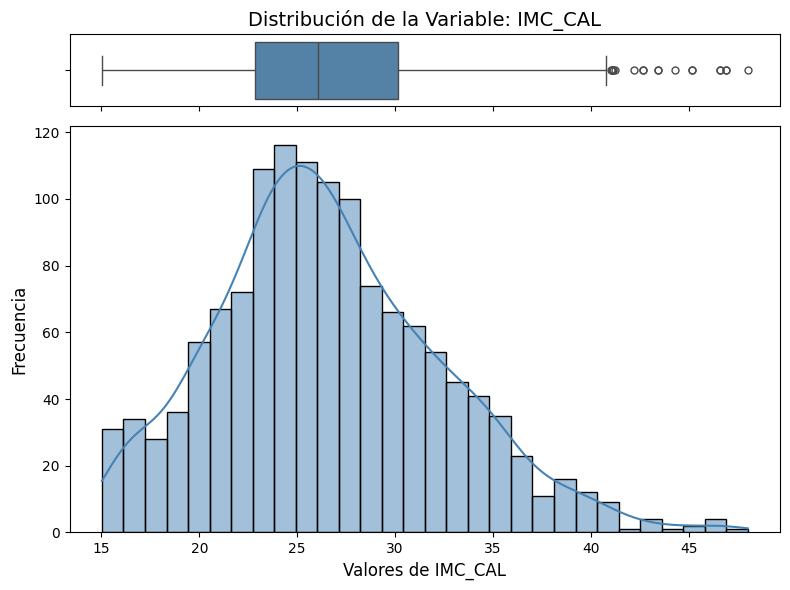

In [403]:
analizar_distribucion(df,"IMC_CAL")

**`TFG calculada:`**

Se calcula la TFG según la fórmula internacional recomendada por la KDIGO.

$$TFGe = 142 \times \min(Cr/\kappa, 1)^\alpha \times \max(Cr/\kappa, 1)^{-1.200} \times 0.9938^{Edad} \times [1.012 \text{ si es mujer}]$$

Donde:
* $Cr$: Creatinina sérica en mg/dL.
* $\kappa$: 0.7 para mujeres, 0.9 para hombres.
* $\alpha$: -0.241 para mujeres, -0.302 para hombres.

In [404]:
import numpy as np

def calcular_tfg_ckdepi(creatinina, edad, sexo):

    sexo = sexo.lower()
    
    es_mujer = (sexo == 'femenino')
    kappa = 0.7 if es_mujer else 0.9
    alpha = -0.302 if not es_mujer else -0.241
    factor_genero = 1.012 if es_mujer else 1.0
    
    t1 = np.power(min(creatinina / kappa, 1), alpha)
    t2 = np.power(max(creatinina / kappa, 1), -1.200)
    
    tfg = 142 * t1 * t2 * (0.9938 ** edad) * factor_genero
    return tfg

In [405]:
df["TFG_CDK_EPI_CAL"] = df.apply(
    lambda row: calcular_tfg_ckdepi(row['Creatinina'], row['Edad'], row['Genero']), 
    axis=1
)

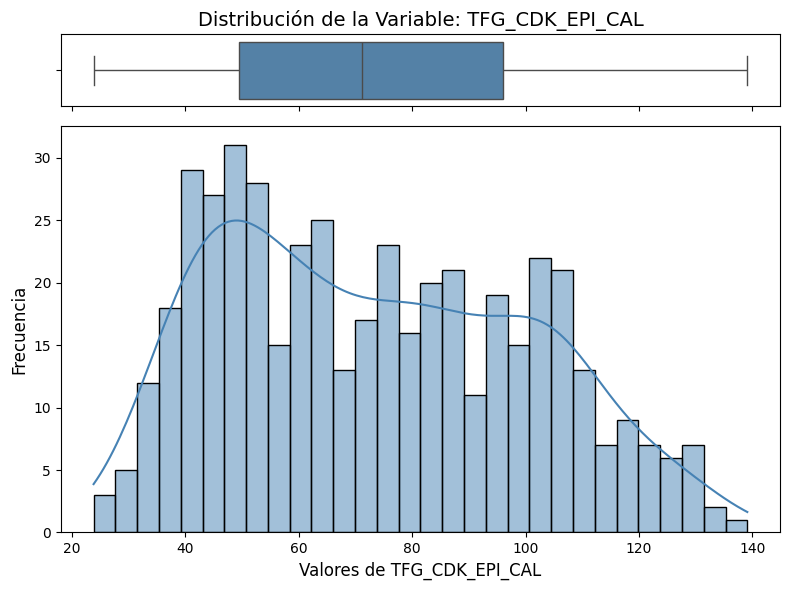

In [406]:
analizar_distribucion(df,"TFG_CDK_EPI_CAL")

In [407]:
bins_erc = [0, 15, 30, 60, 90, np.inf]

labels_erc = [
    "G5: Falla Renal (<15)",
    "G4: Descenso Grave (15-29)",
    "G3: Descenso Moderado (30-59)",
    "G2: Descenso Leve (60-89)",
    "G1: Normal o Elevado (≥90)"
]

df["Estadio_ERC_CAL"] = pd.cut(
    df["TFG_CDK_EPI_CAL"], 
    bins=bins_erc, 
    labels=labels_erc, 
    right=False
)

In [408]:
resumen_var_cat(df['Estadio_ERC_CAL'])

,Categorías,Conteo,Porcentaje
0,nan,861,64.880000
1,G3: Descenso Moderado (30-59),177,13.340000
2,G2: Descenso Leve (60-89),149,11.230000
3,G1: Normal o Elevado (≥90),136,10.250000
4,G4: Descenso Grave (15-29),4,0.300000
5,G5: Falla Renal (<15),0,0.000000


**Creación de la variable dicotómica de estadio de ERC**

In [409]:
df['Estadio_ERC_Binaria'] = df['Estadio_ERC_CAL']

df['Estadio_ERC_Binaria'] = df['Estadio_ERC_Binaria'].replace({
    "G5: Falla Renal (<15)" : 'Moderado',
    "G4: Descenso Grave (15-29)" : 'Moderado',
    "G3: Descenso Moderado (30-59)" : 'Moderado',
    "G2: Descenso Leve (60-89)" : 'No moderado',
    'G1: Normal o Elevado (≥90)':'No moderado'
})

C:\Users\Mari\AppData\Local\Temp\ipykernel_11252\196292477.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Estadio_ERC_Binaria'] = df['Estadio_ERC_Binaria'].replace({


In [410]:
resumen_var_cat(df['Estadio_ERC_Binaria'])

,Categorías,Conteo,Porcentaje
0,nan,861,64.880000
1,No moderado,285,21.480000
2,Moderado,181,13.640000


In [411]:
df['Antecedentes_Familiares'] = df['Antecedentes_Familiares'].replace({
    "ACV " : 'No_ERC',
    'Artritis reumatoide ' : 'No_ERC',
    "Hipertensión Arterial" : 'No_ERC',
    "Diabetes Mellitus" : 'No_ERC',
    'Enfermedad Cardiaca':'No_ERC',
    'Cancer':'No_ERC',
    'Gastritis cronica':'No_ERC',
    'Neurofibromatosis':'No_ERC',
    'Hipotiroidismo':'No_ERC',
    'Parkinson':'No_ERC',
    'Colesterol ':'No_ERC',
    'Hernia lumbosacras ':'No_ERC', 
    'No':'No_ERC'
})

In [412]:
df['Frecuencia_Alcohol'] = df['Frecuencia_Alcohol'].replace({
    "Consumo_Ocasional" : 'Consume',
    'Consumo_Frecuente' : 'Consume',
    "Casi diario" : 'Consume',
    "Consumo_Habitual" : 'Consume',
    'Nunca':'No_consume'
})

In [413]:
df['Municipio_Tamizaje'] = df['Municipio_Tamizaje'].replace({
    "BARRANQUILLA" : 'Zona_urbana',
    'LOMITA ARENA' : 'Zona_rural',
    "SAN JOSE DE SACO" : 'Zona_rural',
    "MARIA LA BAJA" : 'Zona_costera',
    'PALENQUE':'Zona_costera',
    'PONTEZUELA':'Zona_costera'
})

In [414]:
df = df.drop(columns=['GRUPO', 'Fuente_Agua'])

In [415]:
df.to_csv('data_afro_final.csv', index=False)